2025-03-19 14:45:57,007 - INFO - Loading spectral data...
2025-03-19 14:45:57,009 - INFO - Processing RGB data...
2025-03-19 14:45:57,009 - INFO - Normalizing RGB data...
2025-03-19 14:45:57,011 - INFO - Training the model...
2025-03-19 14:45:57,020 - INFO - Epoch 1/1000 - MSE Loss: 0.8991239070892334
2025-03-19 14:45:57,027 - INFO - Epoch 2/1000 - MSE Loss: 0.24060268700122833
2025-03-19 14:45:57,035 - INFO - Epoch 3/1000 - MSE Loss: 0.42127129435539246
2025-03-19 14:45:57,043 - INFO - Epoch 4/1000 - MSE Loss: 0.26488009095191956
2025-03-19 14:45:57,051 - INFO - Epoch 5/1000 - MSE Loss: 0.093135766685009
2025-03-19 14:45:57,059 - INFO - Epoch 6/1000 - MSE Loss: 0.14864489436149597
2025-03-19 14:45:57,066 - INFO - Epoch 7/1000 - MSE Loss: 0.0752980038523674
2025-03-19 14:45:57,074 - INFO - Epoch 8/1000 - MSE Loss: 0.04826226830482483
2025-03-19 14:45:57,082 - INFO - Epoch 9/1000 - MSE Loss: 0.06439480930566788
2025-03-19 14:45:57,090 - INFO - Epoch 10/1000 - MSE Loss: 0.075902789831161

Mean ΔE2000 Error: 5.196267593442131
Max ΔE2000 Error: 15.218165943391643


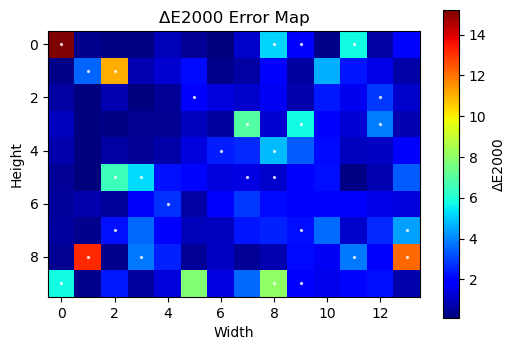

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to RGB using XYZ conversion.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    
    # Convert XYZ to RGB
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_fuji-frame4.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref   = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')

rgb_input_2d = rgb_input.reshape(-1, rgb_input.shape[-1])
rgb_ref_2d   = rgb_ref.reshape(-1, rgb_ref.shape[-1])

scaler_input = StandardScaler()
scaler_ref = StandardScaler()
X_norm = scaler_input.fit_transform(rgb_input_2d)
Y_norm = scaler_ref.fit_transform(rgb_ref_2d)

X_full = X_norm.reshape(rgb_input.shape)
Y_full = Y_norm.reshape(rgb_ref.shape)

###########################################
# 4. Generate Positional Encoding
###########################################
def generate_positional_encoding(image_size):
    # Generate the x, y positions of the pixels in the image
    height, width = image_size
    x_coords = np.arange(0, width)
    y_coords = np.arange(0, height)
    
    # Create grid of (x, y) coordinates
    x_grid, y_grid = np.meshgrid(x_coords, y_coords)
    
    # Flatten the grid and stack the coordinates
    pos_encoding = np.stack([x_grid.flatten(), y_grid.flatten()], axis=1)
    return pos_encoding

# Generate positional encoding for the image
image_size = rgb_input.shape[:2]
positional_encoding = generate_positional_encoding(image_size)

# Concatenate RGB data and positional encoding
X_full_pos = np.concatenate([X_full.reshape(-1, 3), positional_encoding], axis=1)
Y_full_pos = np.concatenate([Y_full.reshape(-1, 3), positional_encoding], axis=1)

###########################################
# 5. Prepare training data with positional encoding
###########################################
X_flat = X_full_pos
Y_flat = Y_full_pos

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 6. Define a simple MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# Model, optimizer, and loss function
model = SimpleMLP(input_size=5, hidden_size=128, output_size=3)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
loss_function = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)  # Reduce LR every 200 epochs


###########################################
# 7. Training loop (using MSE loss in RGB space)

epochs = 1000
batch_size = 4

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        
        # Extract only RGB values (the first 3 values) for loss calculation
        Y_pred_rgb = Y_pred[:, :3]  # Only RGB from prediction
        Y_batch_rgb = Y_batch[:, :3]  # Only RGB from target
        
        loss = loss_function(Y_pred_rgb, Y_batch_rgb)  # Compute loss on RGB values only
        loss.backward()
        optimizer.step()
    
    scheduler.step()  # Reduce learning rate
    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')


###########################################
# 8. Apply correction and evaluate with ΔE2000
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full_pos.reshape(-1, 5)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_rgb = scaler_ref.inverse_transform(corrected_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

# Convert corrected and reference RGB to Lab
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref = color.rgb2lab(rgb_ref)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab)

# Compute mean ΔE2000 error
error_map_flat = error_map.reshape(-1)
test_error_values = error_map_flat[test_indices]
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)
print("Mean ΔE2000 Error:", mean_error_test)
print("Max ΔE2000 Error:", max_error_test)

# Get train set pixel positions in the image
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()
